# KNN-UCB vs. UCBogram: quickstart

This notebook is a minimal, fast-running demo of the two contextual bandit
policies implemented in this repository:

- **KNN-UCB** (Reeve, Mellor & Brown, 2018), with the ternary-search speedup
  described in the accompanying report.
- **UCBogram** (Rigollet & Zeevi, 2010).

It runs a much smaller version of the dimension sweep in `experiments/knn_ucb_vs_ucbogram.py`
(see the report, Section 5.4, for the full-scale result) so it finishes in a
few seconds. For the full reproduction, use the scripts in `experiments/`
directly -- see the top-level README.

In [1]:
import sys
sys.path.insert(0, "../src")

import math
import numpy as np
import matplotlib.pyplot as plt

from bandits import ContextBandit, knn_ucb, ucbogram

## A 2-armed contextual bandit

Rewards depend on a 2-dimensional latent context `z`; the policy only ever
observes `z` mapped into a higher-dimensional ambient space via `h`. Here we
use a simple polynomial `h` so the notebook stays self-contained -- the
experiment script instead draws `h` at random from a small basis-function
family, as described in the report.

In [2]:
def make_bandit(noise_std=0.5):
    reward_fns = [
        lambda z: math.sin(4 * math.pi * z[0]) * math.sin(4 * math.pi * z[1]),
        lambda z: math.cos(3 * math.pi * z[0]) * math.cos(3 * math.pi * z[1]),
    ]
    noise = lambda z: np.random.normal(0, noise_std)
    return ContextBandit(reward_fns, noise)


AMBIENT_DIM = 8

def h(z):
    # z in [0, 1]^2 -> R^AMBIENT_DIM, a fixed (non-random) polynomial embedding
    powers = np.arange(1, AMBIENT_DIM + 1)
    return (z[0] ** powers) * (z[1] ** powers[::-1])

## Run both policies on the same context sequence

In [3]:
rng = np.random.default_rng(0)
n_rounds = 4000
latent_contexts = rng.uniform(0, 1, size=(n_rounds, 2))

knn_regret = knn_ucb(make_bandit(), latent_contexts, theta=1.0, phi=lambda t: 6.0, k_max=200, h=h)
ucbogram_regret = ucbogram(make_bandit(), latent_contexts, m=4, lo=0, hi=1, h=h)

print(f"Final pseudo-regret -- KNN-UCB: {knn_regret[-1]:.1f}, UCBogram: {ucbogram_regret[-1]:.1f}")

Final pseudo-regret -- KNN-UCB: 597.7, UCBogram: 790.6


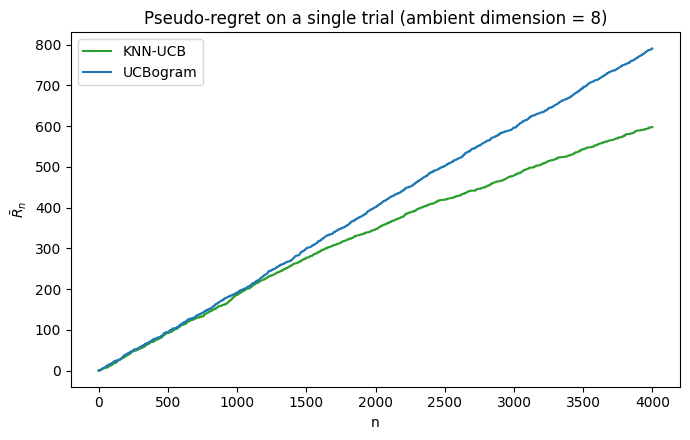

In [4]:
plt.figure(figsize=(7, 4.5))
plt.plot(knn_regret, label="KNN-UCB", color="tab:green")
plt.plot(ucbogram_regret, label="UCBogram", color="tab:blue")
plt.xlabel("n")
plt.ylabel(r"$\bar{R}_n$")
plt.title(f"Pseudo-regret on a single trial (ambient dimension = {AMBIENT_DIM})")
plt.legend()
plt.tight_layout()
plt.show()

## Next steps

- `python experiments/knn_ucb_vs_ucbogram.py` averages several trials across
  a sweep of ambient dimensions and saves the comparison plot (this is what
  produces the report's Figure 8-style result).
- `python experiments/etc_vs_ucb.py` reproduces the stochastic-bandit
  comparison between ETC and UCB (report Figure 3).
- See `docs/report.pdf` for the full write-up: definitions, regret bounds,
  and the reasoning behind both policies.